Business question: How can a telecommunications company identify customers at risk of churn? How might the company decide how to assign priority?

Analytical approach: Analyze attributes associated with churn, develop predictive models for churn risk, and combine predicted churn risk with customer value to identify retention priorities.

Note: Predictive models do not establish which retention interventions will causally prevent churn

In [122]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.info()
df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [123]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [124]:
df["Churn"].value_counts(normalize=True) # to get percentage

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

Let us interpret this data:

- There are 7043 customers
    - gender, seniority, relationship status, and dependents are recorded
- Services:
    - PhoneService
    - MultipleLines
    - Intern#   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  PaymentMethod     7043 non-null   str    
 18  MonthlyCharges    7043 non-null   float64
 19  TotalCharges      7043 non-null   str    
 20  Churn             7043 non-null   str    
dtypes: float64(1), int64(2), str(18)
etService
    - OnlineSecurity
    - OnlineBackup
    - DeviceProtection
    - TechSupport
    - StreamingTV
    - StreamingMovies
- Billing:
    - PaperlessBilling
    - PaymentMethod
    - MonthlyCharges
    - TotalCharges
- Each customer is either tenure or contract
    - contract: month-to-month, one year, or two year
    - tenure: time with company
- Churn rate is 26.54%

Now, let's explore the churn rates based on contract and tenure

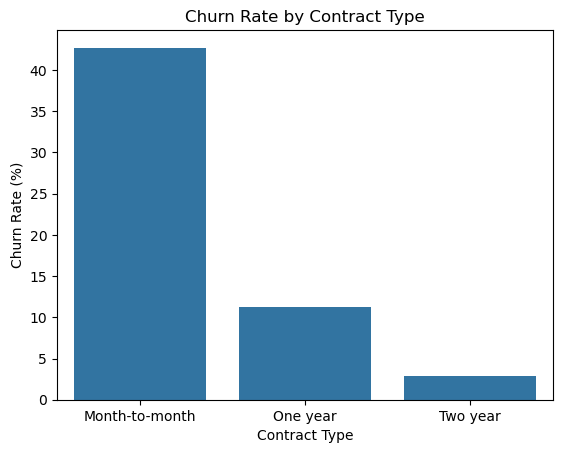

In [125]:
# map yes/no answers to numberic values
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

churn_rate = df.groupby("Contract")["Churn"].mean() * 100

# Churn by Contract Type
sns.barplot(
    x=churn_rate.index,
    y=churn_rate.values
)

plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Contract Type")
plt.show()

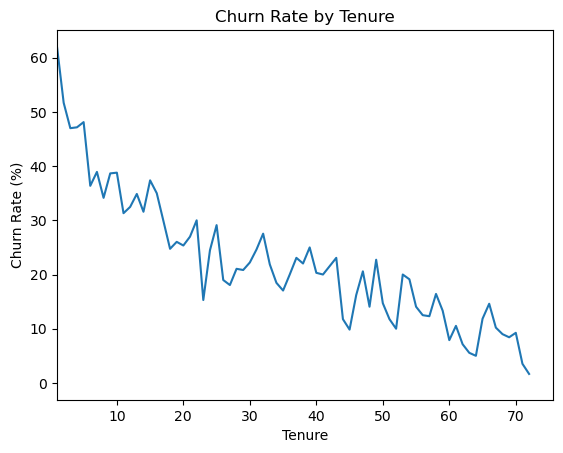

In [126]:
churn_rate = df.groupby("tenure")["Churn"].mean() * 100

# Churn by Tenure
sns.lineplot(
    x=churn_rate.index,
    y=churn_rate.values
)

plt.xlim(left=1)  # Tenures start at 1 monthplt.ylim(bottom=50)  # y-axis starts at 50

plt.xlabel("Tenure")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Tenure")
plt.show()

   TenureGroup        Contract      Churn
0         0-12  Month-to-month  51.354062
1         0-12        One year  10.569106
2         0-12        Two year   0.000000
3        13-24  Month-to-month  37.720488
4        13-24        One year   8.121827
5        13-24        Two year   0.000000
6        25-36  Month-to-month  32.510288
7        25-36        One year   8.000000
8        25-36        Two year   2.083333
9        37-48  Month-to-month  33.544304
10       37-48        One year  13.059701
11       37-48        Two year   2.247191
12       49-60  Month-to-month  27.777778
13       49-60        One year  13.707165
14       49-60        Two year   3.971119
15       61-72  Month-to-month  22.222222
16       61-72        One year  12.140575
17       61-72        Two year   3.144016


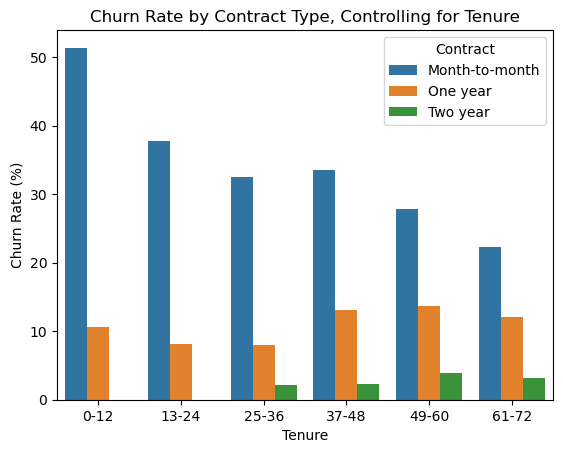

In [127]:
churn_rate = df.groupby("tenure")["Churn"].mean() * 100

# Churn by Contract by 12 Month Tenure Bands
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=["0-12", "13-24", "25-36", "37-48", "49-60", "61-72"]
)

churn_by_tenure_contract = (
    df.groupby(["TenureGroup", "Contract"], observed=True)["Churn"]
      .mean()
      .mul(100)
      .reset_index()
)

print(churn_by_tenure_contract)

sns.barplot(
    data=churn_by_tenure_contract,
    x="TenureGroup",
    y="Churn",
    hue="Contract"
)

plt.ylabel("Churn Rate (%)")
plt.xlabel("Tenure")
plt.title("Churn Rate by Contract Type, Controlling for Tenure")
plt.show()


Customers on month-to-month contracts are significantly more likely to churn; roughly 4 times as likely than those with a one year contract, and roughly 16 times as likely than those with a two year contract

The data for tenure length against churn rate shows that the length of a tenure corresponds to lower churn rates the longer a tenure is.

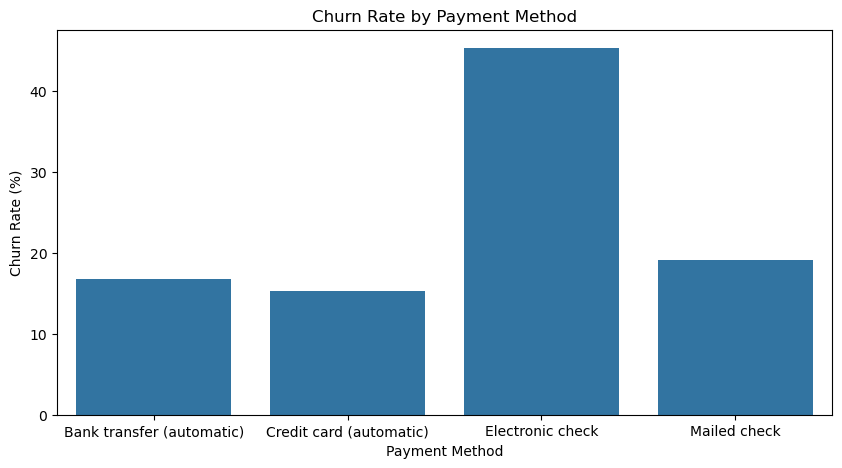

In [128]:
churn_rate = df.groupby("PaymentMethod")["Churn"].mean() * 100

# Churn by Billing Method
plt.figure(figsize=(10, 5))
sns.barplot(
    x=churn_rate.index,
    y=churn_rate.values
)

plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Payment Method")
plt.show()

Customers who pay via electronic cheques churn at a much higher rate than

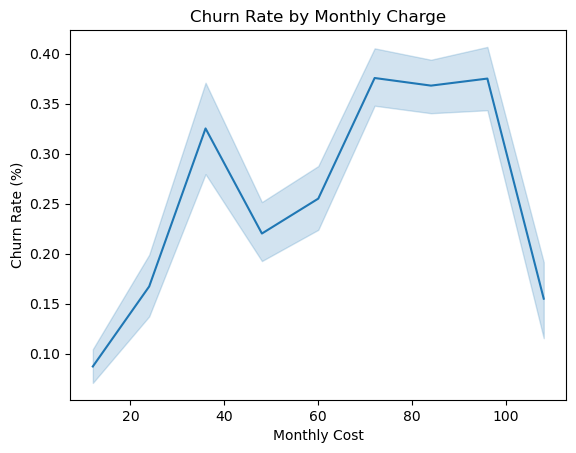

In [144]:
churn_rate = df.groupby("MonthlyCharges")["Churn"].mean() * 100

intervals=[]
for i in range(20):
    intervals.append(i*(120/10))

sns.lineplot(
    data=df,
    x=pd.cut(
        df["MonthlyCharges"],
        bins=intervals,
        labels=intervals[:-1]
    ),
    y="Churn"
)

#sns.lineplot(
#    x=churn_rate.index,
#    y=churn_rate.values
#)

plt.xlabel("Monthly Cost")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Monthly Charge")
plt.show()

In [150]:
# ============================================================
# 5. FEATURE ENGINEERING & TRAIN/TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Target
y = df["Churn"]

# Remove identifiers and target columns
X = df.drop(columns=["customerID", "Churn"])

# Identify numerical and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["str", "string"]).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"\nTraining observations: {len(X_train):,}")
print(f"Testing observations:  {len(X_test):,}")

# Preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("\nPreprocessing pipeline created.")

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']

Training observations: 5,634
Testing observations:  1,409

Preprocessing pipeline created.


In [152]:
# Logical Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
import matplotlib.pyplot as plt

# Create model pipeline
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

# Train
logistic_model.fit(X_train, y_train)

# Predictions
y_pred = logistic_model.predict(X_test)

# Probability of churn
y_prob = logistic_model.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# Model evaluation
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("LOGISTIC REGRESSION PERFORMANCE")
print("--------------------------------")
print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 Score:  {f1:.3f}")
print(f"ROC-AUC:   {roc_auc:.3f}")

print("\nClassification Report")
print("---------------------")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Stayed", "Churned"]
))

LOGISTIC REGRESSION PERFORMANCE
--------------------------------
Accuracy:  0.793
Precision: 0.629
Recall:    0.540
F1 Score:  0.581
ROC-AUC:   0.840

Classification Report
---------------------
              precision    recall  f1-score   support

      Stayed       0.84      0.89      0.86      1035
     Churned       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



/opt/conda/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/conda/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


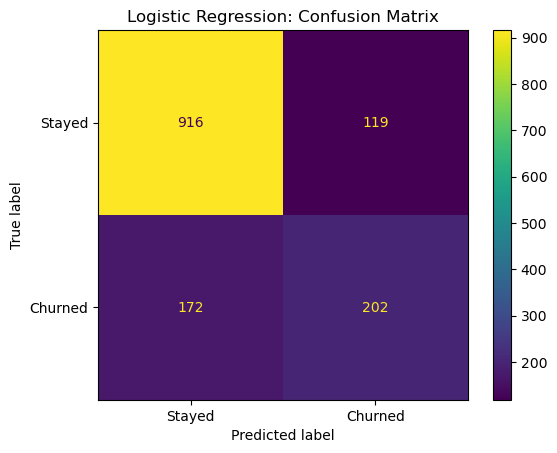

In [153]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"
)

disp.plot()
plt.title("Logistic Regression: Confusion Matrix")
plt.show()

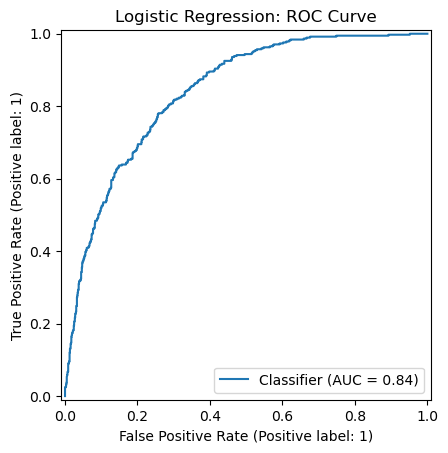

In [155]:
# ROC Curve

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Logistic Regression: ROC Curve")
plt.show()

In [156]:
print(f"ROC-AUC: {roc_auc:.3f}")

ROC-AUC: 0.840


In [159]:
# Per Customer Churn Predictions

results = X_test.copy()

results["actual_churn"] = y_test
results["predicted_churn"] = y_pred
results["churn_probability"] = y_prob

# Add customer ID back
results["customerID"] = df.loc[results.index, "customerID"]

# Put customer ID first
results = results[
    ["customerID", "actual_churn", "predicted_churn", "churn_probability"]
    + [
        col for col in results.columns
        if col not in [
            "customerID",
            "actual_churn",
            "predicted_churn",
            "churn_probability"
        ]
    ]
]

# Highest-risk customers first
results = results.sort_values(
    "churn_probability",
    ascending=False
)

results.head(20)

,customerID,actual_churn,predicted_churn,churn_probability,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,TenureGroup
3380,5178-LMXOP,1,1,0.871149,Male,1,Yes,No,1,Yes,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.10,95.1,0-12
6866,0295-PPHDO,1,1,0.851500,Male,0,No,No,1,Yes,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.45,95.45,0-12
2631,6861-XWTWQ,1,1,0.847206,Male,1,Yes,No,7,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.25,665.45,0-12
6894,1400-MMYXY,1,1,0.845269,Male,1,Yes,No,3,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.90,334.65,0-12
6365,8884-ADFVN,1,1,0.844485,Male,1,Yes,No,7,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,101.95,700.85,0-12
2797,6023-YEBUP,1,1,0.841340,Male,0,No,No,3,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.95,329.95,0-12
2464,2609-IAICY,1,1,0.838570,Female,0,No,No,1,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,77.15,77.15,0-12
3727,9057-SIHCH,1,1,0.838366,Female,0,No,No,3,Yes,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,96.60,291.9,0-12
4585,1069-XAIEM,1,1,0.831145,Female,1,No,No,1,Yes,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.05,85.05,0-12
3346,2545-EBUPK,0,1,0.827620,Female,1,No,No,2,Yes,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,84.05,186.05,0-12


In [161]:
# Simple annual revenue proxy
results["annual_value"] = results["MonthlyCharges"] * 12

# Expected annual revenue at risk
results["expected_revenue_at_risk"] = (
    results["churn_probability"] * results["annual_value"]
)

# Rank customers by expected value at risk
results = results.sort_values(
    "expected_revenue_at_risk",
    ascending=False
)

# Show highest-priority customers
results[
    [
        "customerID",
        "churn_probability",
        "MonthlyCharges",
        "tenure",
        "Contract",
        "annual_value",
        "expected_revenue_at_risk"
    ]
].head(20)

,customerID,churn_probability,MonthlyCharges,tenure,Contract,annual_value,expected_revenue_at_risk
6894,1400-MMYXY,0.845269,105.90,3,Month-to-month,1270.8,1074.168099
6365,8884-ADFVN,0.844485,101.95,7,Month-to-month,1223.4,1033.143361
3956,4587-VVTOX,0.806967,105.30,6,Month-to-month,1263.6,1019.682915
2797,6023-YEBUP,0.841340,100.95,3,Month-to-month,1211.4,1019.199651
2631,6861-XWTWQ,0.847206,99.25,7,Month-to-month,1191.0,1009.022747
3380,5178-LMXOP,0.871149,95.10,1,Month-to-month,1141.2,994.155694
1568,3292-PBZEJ,0.742877,111.40,11,Month-to-month,1336.8,993.077782
2294,2027-FECZV,0.774865,106.70,12,Month-to-month,1280.4,992.136860
2448,9221-OTIVJ,0.787014,104.85,14,Month-to-month,1258.2,990.220404
6866,0295-PPHDO,0.851500,95.45,1,Month-to-month,1145.4,975.308044


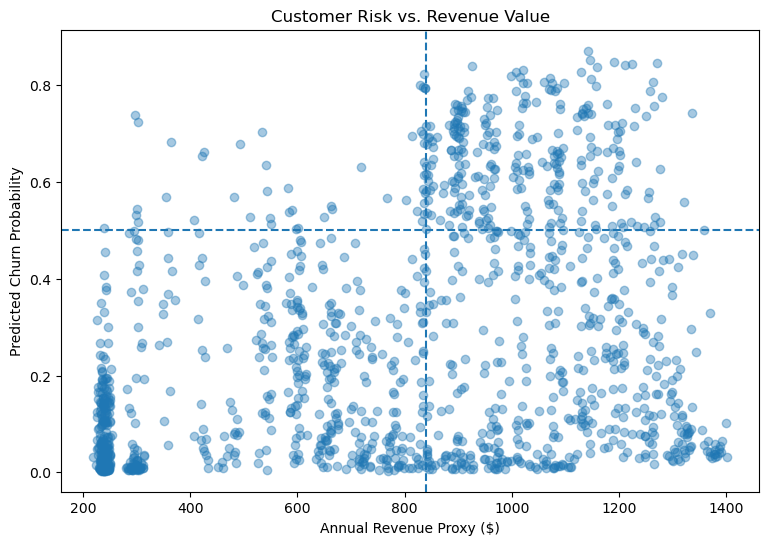

In [162]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.scatter(
    results["annual_value"],
    results["churn_probability"],
    alpha=0.4
)

plt.xlabel("Annual Revenue Proxy ($)")
plt.ylabel("Predicted Churn Probability")
plt.title("Customer Risk vs. Revenue Value")

plt.axhline(0.5, linestyle="--")
plt.axvline(results["annual_value"].median(), linestyle="--")

plt.show()

In [163]:
median_value = results["annual_value"].median()

results["priority_segment"] = "Low Risk / Low Value"

results.loc[
    (results["churn_probability"] >= 0.5) &
    (results["annual_value"] >= median_value),
    "priority_segment"
] = "High Risk / High Value"

results.loc[
    (results["churn_probability"] >= 0.5) &
    (results["annual_value"] < median_value),
    "priority_segment"
] = "High Risk / Low Value"

results.loc[
    (results["churn_probability"] < 0.5) &
    (results["annual_value"] >= median_value),
    "priority_segment"
] = "Low Risk / High Value"

results["priority_segment"].value_counts()

priority_segment
Low Risk / Low Value      657
Low Risk / High Value     431
High Risk / High Value    274
High Risk / Low Value      47
Name: count, dtype: int64

In [164]:
results.groupby("priority_segment").agg(
    customers=("customerID", "count"),
    total_revenue_at_risk=("expected_revenue_at_risk", "sum"),
    avg_churn_probability=("churn_probability", "mean")
).sort_values("total_revenue_at_risk", ascending=False)

,customers,total_revenue_at_risk,avg_churn_probability
priority_segment,,,
High Risk / High Value,274,185049.870683,0.656852
Low Risk / High Value,431,87357.229753,0.183477
Low Risk / Low Value,657,45641.363760,0.134449
High Risk / Low Value,47,18201.841554,0.612769


# Recommendations
Focus on improving churn rates for Month-to-month contracts, or convert them to other plans.

Automate Payment Channels: Currently, 2,365 users rely on electronic checks. Transitioning these accounts to automatic credit card payments or direct bank transfers will reduce friction-based cancellations and accidental payment lapses.

Target Early-Tenure Intervention: The bottom quartile of the customer base has a tenure of just 9 months or less. Deploy proactive retention workflows and technical onboarding support during this critical first-year window to prevent early churn.

Leverage Digital Touchpoints: With 4,171 customers utilizing paperless billing, the company has a direct digital channel for targeted marketing. Utilize this channel to push automated service upgrade offers to the 6,361 users who already have active phone service.

# Executive Summary

The current portfolio exhibits a baseline customer churn rate of 26.54% across its 7,043-subscriber base. Value destruction is heavily concentrated within the month-to-month subscriber cohort, which visually demonstrates the highest attrition levels and represents 3,875 customers. A significant portion of the base also operates without structural demographic retention barriers, as 4,933 customers have no dependents and 3,641 have no partners. Addressing the structural imbalance in the contract mix is the most direct lever to stabilize recurring revenue and improve enterprise value.  
